In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [2]:
nav = pd.read_csv("C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/data/processed/02_nav_history.csv")

performance = pd.read_csv("C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/data/processed/07_scheme_performance.csv")

benchmark = pd.read_csv("C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/data/processed/10_benchmark_indices.csv")

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

# Task 1 - Daily Return

daily_return = nav_today / nav_yesterday - 1

In [4]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [5]:
# Save CSV

nav.to_csv(
    "C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/reports/returns_computed.csv",
    index=False
)

# Task 2 - CAGR

PDF me 1,3,5 year CAGR bola hai

In [6]:
cagr = (
    nav.groupby("amfi_code")
       .agg(
           start_nav=("nav","first"),
           end_nav=("nav","last"),
           days=("date","count")
       )
       .reset_index()
)

In [7]:
cagr["cagr"] = (
    (cagr["end_nav"] / cagr["start_nav"])
    **
    (252 / cagr["days"])
) - 1

In [8]:
cagr.to_csv(
    "C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/reports/cagr_report.csv",
    index=False
)

# Task 3 - Sharpe Ratio

PDF me Risk Free Rate = 6.5% diya hai.

In [9]:
risk_free = 0.065

sharpe = (
    nav.groupby("amfi_code")["daily_return"]
       .agg(["mean","std"])
       .reset_index()
)

sharpe["sharpe_ratio"] = (
    (sharpe["mean"]*252 - risk_free)
    /
    (sharpe["std"]*np.sqrt(252))
)

In [10]:
sharpe.to_csv(
    "C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/reports/sharpe_values.csv",
    index=False
)

# Task 4 - Sortino Ratio

PDF Formula:
Sortino = (Rp − Rf) / Downside Std

In [11]:
risk_free = 0.065

sortino_list = []

for amfi, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    downside = returns[returns < 0]

    downside_std = downside.std()

    annual_return = returns.mean() * 252

    if pd.notna(downside_std) and downside_std != 0:
        sortino = (annual_return - risk_free) / (downside_std * np.sqrt(252))
    else:
        sortino = np.nan

    sortino_list.append([amfi, sortino])

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [12]:
sortino_df.to_csv(
    "C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/reports/sortino_values.csv",
    index=False
)

# Task 5 - Alpha & Beta

PDF: Benchmark ke against Alpha aur Beta calculate karo.

In [13]:
benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = (
    benchmark["close_value"].pct_change()
)

In [14]:
benchmark_returns = benchmark[["date", "benchmark_return"]]

alpha_beta = []

for amfi, group in nav.groupby("amfi_code"):

    df = group.merge(
        benchmark_returns,
        on="date",
        how="inner"
    )

    df = df.dropna()

    if len(df) > 30:

        slope, intercept, _, _, _ = linregress(
            df["benchmark_return"],
            df["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

    else:

        alpha = np.nan
        beta = np.nan

    alpha_beta.append([amfi, alpha, beta])

alpha_beta = pd.DataFrame(
    alpha_beta,
    columns=["amfi_code", "alpha", "beta"]
)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037661,-0.000003
1,100025,0.044818,-0.000003
2,100033,0.265138,0.000012
3,101206,0.208464,0.000011
4,101207,0.109861,-0.000005


In [15]:
alpha_beta.to_csv(
    "C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/reports/alpha_beta.csv",
    index=False
)

# Task 6 - Maximum Drawdown

PDF Formula

NAV / Running Max − 1

In [16]:
drawdown = []

for amfi, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    running_max = group["nav"].cummax()

    dd = (group["nav"] / running_max) - 1

    drawdown.append(
        [amfi, dd.min()]
    )

drawdown = pd.DataFrame(
    drawdown,
    columns=["amfi_code", "max_drawdown"]
)

drawdown.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [17]:
drawdown.to_csv(
    "C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/reports/max_drawdown.csv",
    index=False
)

# Task 7 - Fund Scorecard

PDF Formula

30% Return

25% Sharpe

20% Alpha

15% Expense Ratio

10% Max Drawdown

In [25]:
score = performance.copy()

score = score.merge(
    sharpe[["amfi_code", "sharpe_ratio"]],
    on="amfi_code",
    how="left"
)

score = score.merge(
    alpha_beta,
    on="amfi_code",
    how="left"
)

score = score.merge(
    drawdown,
    on="amfi_code",
    how="left"
)
print(score.columns)


Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha_x', 'beta_x', 'sharpe_ratio_x',
       'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore',
       'expense_ratio_pct', 'morningstar_rating', 'risk_grade',
       'sharpe_ratio_y', 'alpha_y', 'beta_y', 'max_drawdown'],
      dtype='object')


In [26]:
score["fund_score"] = (
    score["return_3yr_pct"].rank(pct=True) * 30 +
    score["sharpe_ratio_y"].rank(pct=True) * 25 +
    score["alpha_y"].rank(pct=True) * 20 +
    (1 - score["expense_ratio_pct"].rank(pct=True)) * 15 +
    (1 - score["max_drawdown"].rank(pct=True)) * 10
)


In [27]:
score = score.sort_values(
    by="fund_score",
    ascending=False
)

score.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha_x,...,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,sharpe_ratio_y,alpha_y,beta_y,max_drawdown,fund_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,-13.35,19259,1.43,5,Very High,0.945308,0.295143,0.000013,-0.287060,81.7500
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,...,-21.84,979,1.36,3,High,1.180101,0.278249,0.000025,-0.181885,80.6250
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,-17.01,35124,1.52,4,Very High,0.949796,0.296003,0.000008,-0.311719,77.8125
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,...,-13.67,23185,1.38,5,High,1.093699,0.265138,0.000012,-0.162172,75.3750
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,-19.50,35012,1.45,5,Moderately High,1.306744,0.260693,0.000020,-0.129740,73.6250


In [28]:
score.to_csv(
    "C:/Users/dell/OneDrive/Desktop/Mutual_Fund_Analytics/reports/fund_scorecard.csv",
    index=False
)

# Task 8 - Benchmark Comparison Chart

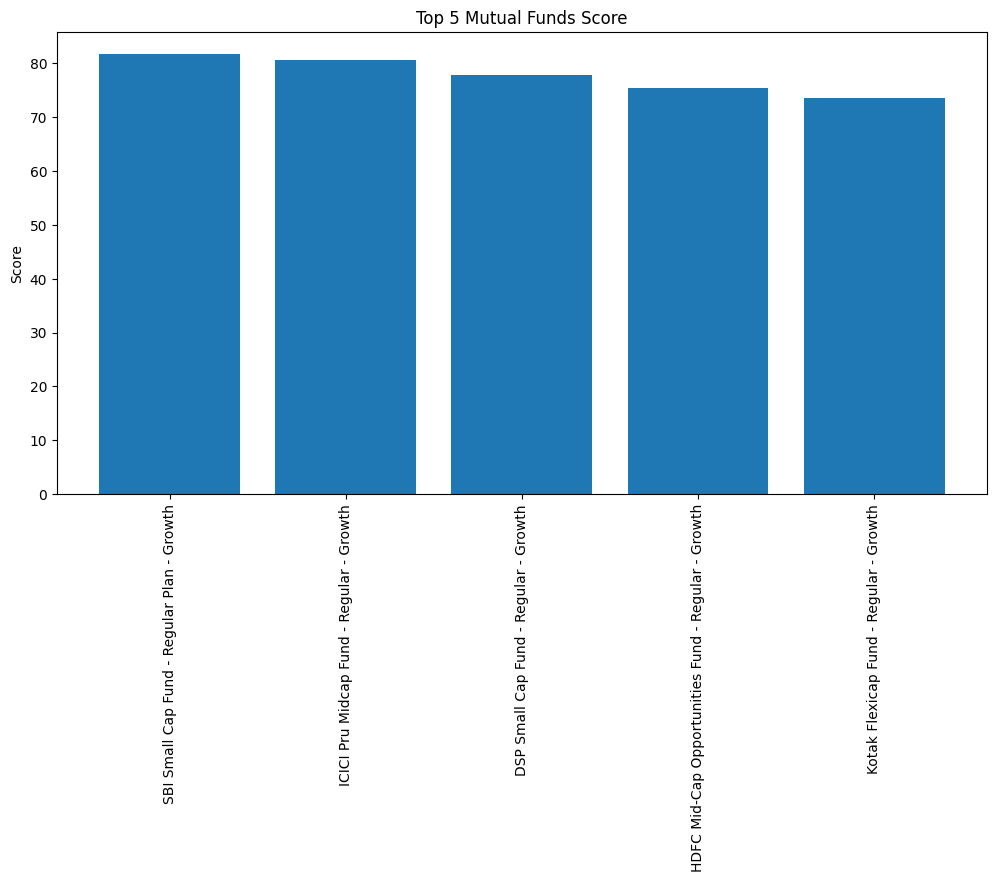

In [29]:
top5 = (
    score
    .sort_values("fund_score", ascending=False)
    .head(5)
)

plt.figure(figsize=(12,6))

plt.bar(
    top5["scheme_name"],
    top5["fund_score"]
)

plt.xticks(rotation=90)
plt.title("Top 5 Mutual Funds Score")
plt.ylabel("Score")
plt.show()